# Combined Analysis Plot

This notebook creates a single plot with 3 subplots showing:
1. Mutation Status Prediction Performance
2. Oncogenic Driver Identification Performance
3. Cancer Type Classification Performance

In [1]:
# Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

from matplotlib import font_manager, rcParams

# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font
rcParams["font.family"] = "Liberation Sans"

# Display names for models
MODEL_DISPLAY_NAMES = {
    'GDD-ENS': 'GDD-ENS',
    'gpt-5': 'GPT-5',
    'gpt-4o': 'GPT-4o',
    'o3-mini': 'o3-mini',
    'medgemma': 'MedGemma-27B',
    'qwen3': 'Qwen3-30B',
    'qwen3-vl-235b-a22b': 'Qwen3-235B',
    'deepseek': 'DeepSeek-Distill-32B',
    'deepseek-r1': 'DeepSeek-R1',
    'claude-sonnet-37': 'Claude-Sonnet-3.7',
    'claude-sonnet-45': 'Claude-Sonnet-4.5',
    'claude-opus-45': 'Claude-Opus-4.5',
    'AlphaMissense': 'AlphaMissense',
    'MetaCH': 'MetaCH'
}

print("✓ Imports loaded")

✓ Imports loaded


In [2]:
# Define the create_model_boxplot_with_dots function
def create_model_boxplot_with_dots(
    metrics_df,
    metric_col='accuracy',
    model_col='model',
    cancer_type_col='cancer_type',
    models_to_include=None,
    model_display_names=None,
    model_colors=None,
    figsize=(12, 8),
    y_label=None,
    title=None,
    y_lim=None,
    fontsize=14,
    dot_alpha=0.6,
    dot_size=80,
    jitter_strength=0.2,
    ax=None,  # Added ax parameter to support subplots
    subplot_wspace=None,  # Width spacing between subplots (e.g., 0.05 for tight, 0.2 for default)
    bold_labels=None,  # List of model names (original keys) to bold in x-axis labels
    model_groups=None,  # List of lists defining model groups for spacing, e.g., [['MetaCH'], ['gpt-5', 'o3-mini'], ...]
    group_spacing=0.5  # Extra spacing between model groups
):
    """
    Create a box plot where x-axis is each model and y-axis is the distribution
    of stratified cancer type metrics. Overlays individual cancer type dots.
    
    Parameters
    ----------
    subplot_wspace : float, optional
        Width spacing between subplots. Smaller values (e.g., 0.05) create tighter
        spacing, larger values (e.g., 0.2) create more space. Default None uses
        matplotlib's default spacing.
    bold_labels : list, optional
        List of model names (original keys, not display names) to render in bold.
    model_groups : list of lists, optional
        Groups of models for adding spacing between them. Each inner list contains
        model names that belong to the same group.
    group_spacing : float, optional
        Extra spacing to add between model groups. Default is 0.5.
    """
    # Default display names and colors
    default_display_names = {
        'GDD-ENS': 'GDD-ENS',
        'gpt-5': 'GPT-5',
        'gpt-4o': 'GPT-4o',
        'o3-mini': 'o3-mini',
        'medgemma': 'MedGemma-27B',
        'qwen3': 'Qwen3-30B',
        'qwen3-vl-235b-a22b': 'Qwen3-235B',
        'deepseek': 'DeepSeek-Distill-32B',
        'deepseek-r1': 'DeepSeek-R1',
        'claude-sonnet-37': 'Claude-Sonnet-3.7',
        'claude-sonnet-45': 'Claude-Sonnet-4.5',
        'claude-opus-45': 'Claude-Opus-4.5',
        'AlphaMissense': 'AlphaMissense',
        'MetaCH': 'MetaCH'
    }

    # Color schemes:
    # Claude family: blues (changed from indigo to be distinct from Qwen purple)
    # DeepSeek family: cyans/teals
    # Qwen family: purples
    default_colors = {
        'GDD-ENS': '#000000',
        'MetaCH': '#000000',
        'AlphaMissense': '#000000',
        'claude-sonnet-37': '#3b82f6',  # blue
        'claude-sonnet-45': '#0038d2',  # darker blue
        'claude-opus-45': '#001449',    # even darker blue
        'gpt-5': '#ffb343',
        'gpt-4o': '#ea580c',
        'o3-mini': '#fb923c',
        'medgemma': '#10b981',
        'qwen3': '#a78bfa',             # light purple
        'qwen3-vl-235b-a22b': '#7c3aed', # darker purple
        'deepseek': '#67e8f9',          # light cyan
        'deepseek-r1': '#06b6d4'        # darker cyan
    }

    if model_display_names is None:
        model_display_names = default_display_names
    if model_colors is None:
        model_colors = default_colors
    if bold_labels is None:
        bold_labels = []

    # Filter and sort data
    df = metrics_df.copy()
    if models_to_include is not None:
        df = df[df[model_col].isin(models_to_include)]
    else:
        models_to_include = df[model_col].unique().tolist()

    df[model_col] = pd.Categorical(df[model_col], categories=models_to_include, ordered=True)
    df = df.sort_values(model_col)

    # Create figure if ax not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=150)
    else:
        fig = ax.get_figure()

    # Apply subplot width spacing if specified
    if subplot_wspace is not None:
        fig.subplots_adjust(wspace=subplot_wspace)

    # Calculate positions with group spacing
    positions = []
    current_pos = 0
    if model_groups is not None:
        # Create a mapping of model to group index
        model_to_group = {}
        for group_idx, group in enumerate(model_groups):
            for model in group:
                model_to_group[model] = group_idx
        
        prev_group = None
        for model in models_to_include:
            curr_group = model_to_group.get(model, -1)
            if prev_group is not None and curr_group != prev_group:
                current_pos += group_spacing  # Add extra space between groups
            positions.append(current_pos)
            current_pos += 1
            prev_group = curr_group
    else:
        positions = list(range(len(models_to_include)))
    
    positions = np.array(positions)

    # Prepare data for box plots
    data_by_model = [df[df[model_col] == model][metric_col].dropna().values
                     for model in models_to_include]

    # Create box plots
    bp = ax.boxplot(
        data_by_model,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='darkred', linewidth=3),
        boxprops=dict(alpha=0.7),
        whiskerprops=dict(linewidth=2),
        capprops=dict(linewidth=2)
    )

    # Color boxes
    for patch, model in zip(bp['boxes'], models_to_include):
        color = model_colors.get(model, '#6b7280')
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(2)

    # Add jittered dots for individual cancer types
    np.random.seed(42)
    for i, model in enumerate(models_to_include):
        model_data = df[df[model_col] == model]
        y_values = model_data[metric_col].values
        jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(y_values))
        x_values = np.ones(len(y_values)) * positions[i] + jitter

        color = model_colors.get(model, '#6b7280')
        ax.scatter(
            x_values, y_values,
            alpha=dot_alpha,
            s=dot_size,
            color=color,
            edgecolors='white',
            linewidth=1,
            zorder=3
        )

    # Formatting
    ax.set_xticks(positions)
    display_labels = [model_display_names.get(m, m) for m in models_to_include]
    ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=fontsize)
    
    # Bold specific labels
    for i, (model, label) in enumerate(zip(models_to_include, ax.get_xticklabels())):
        if model in bold_labels:
            label.set_fontweight('bold')

    if y_label is None:
        y_label = metric_col.replace('_', ' ').title()
        if metric_col == 'accuracy':
            y_label += ' (%)'
    ax.set_ylabel(y_label, fontsize=fontsize + 2, fontweight='bold')

    if title is None:
        title = f'{metric_col.replace("_", " ").title()} Distribution'
    ax.set_title(title, fontsize=fontsize + 4, fontweight='bold', pad=20)

    if y_lim is not None:
        ax.set_ylim(y_lim)

    ax.tick_params(axis='y', labelsize=fontsize)
    ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)

    return fig

print("✓ Function defined")

✓ Function defined


In [3]:
# Load data files
mutation_status_file = "/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/1_mutation_status_prediction/merged_predictions_all_models_ALL_with_chr.csv"
oncogenic_driver_file = "/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/2_oncogenic_driver_identification/merged_predictions_all_models.csv"
cancer_type_file = "/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/3_cancer_type_classification/cancer_type_all_model_results.csv"

df_mutation = pd.read_csv(mutation_status_file)
df_oncogenic = pd.read_csv(oncogenic_driver_file)
df_cancer = pd.read_csv(cancer_type_file)

print("✓ Data loaded")
print(f"  Mutation status: {df_mutation.shape}")
print(f"  Oncogenic driver: {df_oncogenic.shape}")
print(f"  Cancer type: {df_cancer.shape}")

✓ Data loaded
  Mutation status: (34415, 38)
  Oncogenic driver: (13468, 30)
  Cancer type: (102791, 39)


In [4]:
# Process Task 1: Mutation Status Prediction (CHIP vs TUMOR-SOMATIC)
# Models: MetaCH, gpt-5, o3-mini, gpt-4o, medgemma, qwen3, qwen3-vl-235b-a22b, claude-sonnet-37, claude-sonnet-45, claude-opus-45, deepseek, deepseek-r1

task1_models = ['MetaCH', 'gpt-5', 'o3-mini', 'gpt-4o', 'claude-sonnet-37', 'claude-sonnet-45', 'claude-opus-45', 'qwen3', 'qwen3-vl-235b-a22b', 'deepseek', 'deepseek-r1', 'medgemma']

# Get unique cancer types
cancer_types_task1 = df_mutation['CANCER_TYPE'].unique()

# Calculate accuracy by cancer type for each model
task1_results = []
for cancer_type in cancer_types_task1:
    df_cancer_type = df_mutation[df_mutation['CANCER_TYPE'] == cancer_type]
    
    for model in task1_models:
        pred_col = f"{model}_pred"
        
        if pred_col not in df_cancer_type.columns:
            continue
        
        # Get valid predictions
        valid_mask = df_cancer_type[pred_col].notna() & df_cancer_type['ground_truth'].notna()
        df_valid = df_cancer_type[valid_mask]
        
        if len(df_valid) < 10:  # Minimum samples threshold
            continue
        
        y_true = df_valid['ground_truth']
        y_pred = df_valid[pred_col]
        
        accuracy = accuracy_score(y_true, y_pred) * 100
        
        task1_results.append({
            'cancer_type': cancer_type,
            'model': model,
            'accuracy': accuracy,
            'n_samples': len(df_valid)
        })

task1_metrics = pd.DataFrame(task1_results)
print(f"✓ Task 1 processed: {len(task1_metrics)} entries")
print(f"  Cancer types: {task1_metrics['cancer_type'].nunique()}")
print(f"  Models: {task1_metrics['model'].nunique()}")

✓ Task 1 processed: 588 entries
  Cancer types: 49
  Models: 12


In [5]:
# Process Task 2: Oncogenic Driver Identification (Oncogenic vs Benign)
# Models: AlphaMissense, gpt-5, gpt-4o, o3-mini, claude-sonnet-37, claude-sonnet-45, claude-opus-45, deepseek, deepseek-r1, qwen3, qwen3-vl-235b-a22b, medgemma

task2_models = ['AlphaMissense', 'gpt-5', 'o3-mini', 'gpt-4o', 'claude-sonnet-37', 'claude-sonnet-45', 'claude-opus-45', 'qwen3', 'qwen3-vl-235b-a22b', 'deepseek', 'deepseek-r1', 'medgemma']

# Get unique cancer types
cancer_types_task2 = df_oncogenic['CANCER_TYPE'].unique()

# Calculate accuracy by cancer type for each model
task2_results = []
for cancer_type in cancer_types_task2:
    df_cancer_type = df_oncogenic[df_oncogenic['CANCER_TYPE'] == cancer_type]
    
    for model in task2_models:
        pred_col = f"{model}_pred"
        
        if pred_col not in df_cancer_type.columns:
            continue
        
        # Get valid predictions
        valid_mask = df_cancer_type[pred_col].notna() & df_cancer_type['ground_truth'].notna()
        df_valid = df_cancer_type[valid_mask]
        
        if len(df_valid) < 10:  # Minimum samples threshold
            continue
        
        y_true = df_valid['ground_truth']
        y_pred = df_valid[pred_col]
        
        accuracy = accuracy_score(y_true, y_pred) * 100
        
        task2_results.append({
            'cancer_type': cancer_type,
            'model': model,
            'accuracy': accuracy,
            'n_samples': len(df_valid)
        })

task2_metrics = pd.DataFrame(task2_results)
print(f"✓ Task 2 processed: {len(task2_metrics)} entries")
print(f"  Cancer types: {task2_metrics['cancer_type'].nunique()}")
print(f"  Models: {task2_metrics['model'].nunique()}")

✓ Task 2 processed: 720 entries
  Cancer types: 60
  Models: 12


In [6]:
# Process Task 3: Cancer Type Classification
# Models: GDD-ENS, gpt-5, gpt-4o, o3-mini, medgemma, qwen3, qwen3-vl-235b-a22b, deepseek, deepseek-r1, claude-sonnet-37, claude-sonnet-45, claude-opus-45

task3_models = ['GDD-ENS', 'gpt-5', 'o3-mini', 'gpt-4o', 'claude-sonnet-37', 'claude-sonnet-45', 'claude-opus-45', 'qwen3', 'qwen3-vl-235b-a22b', 'deepseek', 'deepseek-r1', 'medgemma']

# Filter out UNKNOWN cancer types
df_cancer_clean = df_cancer[df_cancer['ground_truth'] != 'UNKNOWN'].copy()

# Get cancer types with sufficient samples
cancer_counts = df_cancer_clean['ground_truth'].value_counts()
valid_cancers = cancer_counts[cancer_counts >= 10].index.tolist()
df_cancer_clean = df_cancer_clean[df_cancer_clean['ground_truth'].isin(valid_cancers)]

# Calculate accuracy by cancer type for each model
task3_results = []
for cancer_type in valid_cancers:
    df_cancer_type = df_cancer_clean[df_cancer_clean['ground_truth'] == cancer_type]
    
    for model in task3_models:
        pred_col = f"{model}_pred"
        
        if pred_col not in df_cancer_type.columns:
            continue
        
        # Get valid predictions
        valid_mask = df_cancer_type[pred_col].notna() & df_cancer_type['ground_truth'].notna()
        df_valid = df_cancer_type[valid_mask]
        
        if len(df_valid) == 0:
            continue
        
        y_true = df_valid['ground_truth']
        y_pred = df_valid[pred_col]
        
        accuracy = accuracy_score(y_true, y_pred) * 100
        
        task3_results.append({
            'cancer_type': cancer_type,
            'model': model,
            'accuracy': accuracy,
            'n_samples': len(df_valid)
        })

task3_metrics = pd.DataFrame(task3_results)
print(f"✓ Task 3 processed: {len(task3_metrics)} entries")
print(f"  Cancer types: {task3_metrics['cancer_type'].nunique()}")
print(f"  Models: {task3_metrics['model'].nunique()}")

✓ Task 3 processed: 408 entries
  Cancer types: 34
  Models: 12


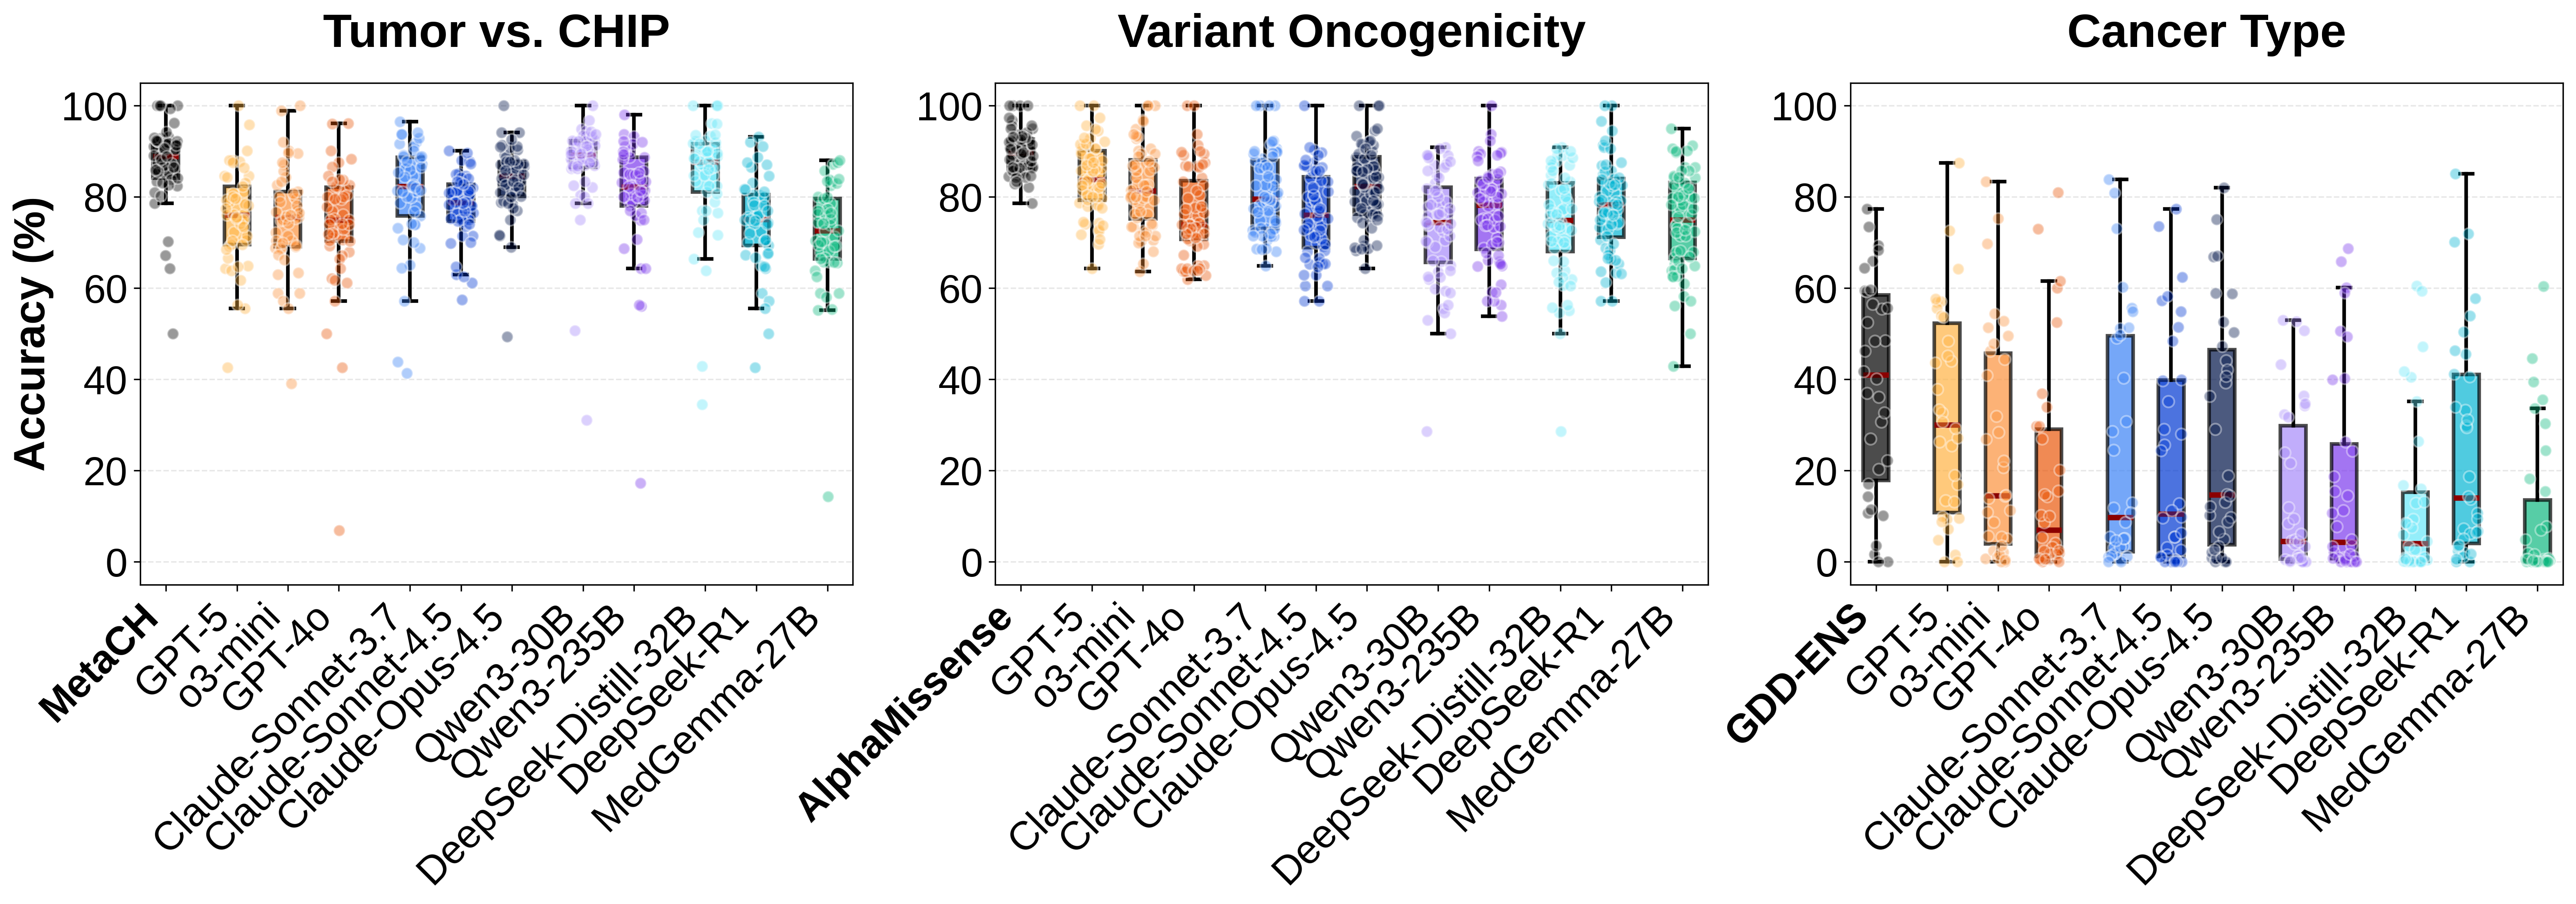


✓ Combined plot created and saved!
  - combined_analysis_plot.pdf
  - combined_analysis_plot.png


In [21]:
# Create combined plot with 3 subplots
# Adjust subplot_wspace to control gap between subplots (smaller = tighter, e.g., 0.05)
SUBPLOT_WSPACE = 0.2  # Adjustable parameter for subplot spacing
GROUP_SPACING = 0.4    # Extra spacing between model groups

# Define model groups for spacing
TASK1_GROUPS = [
    ['MetaCH'],  # Baseline
    ['gpt-5', 'o3-mini', 'gpt-4o'],  # OpenAI
    ['claude-sonnet-37', 'claude-sonnet-45', 'claude-opus-45'],  # Claude
    ['qwen3', 'qwen3-vl-235b-a22b'],  # Qwen
    ['deepseek', 'deepseek-r1'],  # DeepSeek
    ['medgemma']  # MedGemma
]

TASK2_GROUPS = [
    ['AlphaMissense'],  # Baseline
    ['gpt-5', 'o3-mini', 'gpt-4o'],  # OpenAI
    ['claude-sonnet-37', 'claude-sonnet-45', 'claude-opus-45'],  # Claude
    ['qwen3', 'qwen3-vl-235b-a22b'],  # Qwen
    ['deepseek', 'deepseek-r1'],  # DeepSeek
    ['medgemma']  # MedGemma
]

TASK3_GROUPS = [
    ['GDD-ENS'],  # Baseline
    ['gpt-5', 'o3-mini', 'gpt-4o'],  # OpenAI
    ['claude-sonnet-37', 'claude-sonnet-45', 'claude-opus-45'],  # Claude
    ['qwen3', 'qwen3-vl-235b-a22b'],  # Qwen
    ['deepseek', 'deepseek-r1'],  # DeepSeek
    ['medgemma']  # MedGemma
]

# Labels to bold (baseline models)
BOLD_LABELS = ['MetaCH', 'AlphaMissense', 'GDD-ENS']

fig, axes = plt.subplots(1, 3, figsize=(24, 5), dpi=300)

# Task 1: Mutation Status Prediction
create_model_boxplot_with_dots(
    figsize=(8, 6),
    metrics_df=task1_metrics,
    metric_col='accuracy',
    models_to_include=task1_models,
    title='Tumor vs. CHIP',
    y_label='Accuracy (%)',
    y_lim=[-5, 105],
    fontsize=22,
    dot_alpha=0.4,
    dot_size=40,
    jitter_strength=0.25,
    ax=axes[0],
    subplot_wspace=SUBPLOT_WSPACE,
    bold_labels=BOLD_LABELS,
    model_groups=TASK1_GROUPS,
    group_spacing=GROUP_SPACING
)

# Task 2: Oncogenic Driver Identification
create_model_boxplot_with_dots(
    figsize=(8, 6),
    metrics_df=task2_metrics,
    metric_col='accuracy',
    models_to_include=task2_models,
    title='Variant Oncogenicity',
    y_label=' ',
    y_lim=[-5, 105],
    fontsize=22,
    dot_alpha=0.4,
    dot_size=40,
    jitter_strength=0.25,
    ax=axes[1],
    bold_labels=BOLD_LABELS,
    model_groups=TASK2_GROUPS,
    group_spacing=GROUP_SPACING
)

# Task 3: Cancer Type Classification
create_model_boxplot_with_dots(
    figsize=(8, 6),
    metrics_df=task3_metrics,
    metric_col='accuracy',
    models_to_include=task3_models,
    title='Cancer Type',
    y_label=' ',
    y_lim=[-5, 105],
    fontsize=22,
    dot_alpha=0.4,
    dot_size=40,
    jitter_strength=0.25,
    ax=axes[2],
    bold_labels=BOLD_LABELS,
    model_groups=TASK3_GROUPS,
    group_spacing=GROUP_SPACING
)


# plt.tight_layout()
plt.savefig('plots/combined_analysis_plot_accuracy.svg', dpi=300, bbox_inches='tight')
plt.savefig('plots/combined_analysis_plot_accuracy.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/combined_analysis_plot_accuracy.pdf', dpi=300, bbox_inches='tight')

plt.show()

print("\n✓ Combined plot created and saved!")
print("  - combined_analysis_plot.pdf")
print("  - combined_analysis_plot.png")

In [8]:
# Calculate IQR (Q3 - Q1) for F1 scores by model
print("=====Task 1 Accuracy IQR=====")
iqr_by_model = task1_metrics.groupby('model')['accuracy'].agg(
    Q1=lambda x: x.quantile(0.25),
    median=lambda x: x.quantile(0.50),
    Q3=lambda x: x.quantile(0.75),
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
).round(3)

print(iqr_by_model.sort_values('IQR'))
print("=====Task 2 Accuracy IQR=====")
iqr_by_model = task2_metrics.groupby('model')['accuracy'].agg(
    Q1=lambda x: x.quantile(0.25),
    median=lambda x: x.quantile(0.50),
    Q3=lambda x: x.quantile(0.75),
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
).round(3)

print(iqr_by_model.sort_values('IQR'))
print("=====Task 3 Accuracy IQR=====")
iqr_by_model = task3_metrics.groupby('model')['accuracy'].agg(
    Q1=lambda x: x.quantile(0.25),
    median=lambda x: x.quantile(0.50),
    Q3=lambda x: x.quantile(0.75),
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
).round(3)

print(iqr_by_model.sort_values('IQR'))

=====Task 1 Accuracy IQR=====
                        Q1  median      Q3     IQR
model                                             
qwen3               86.443  89.134  92.257   5.814
claude-opus-45      80.108  84.615  87.736   7.628
claude-sonnet-45    74.716  78.786  82.746   8.030
MetaCH              84.074  88.889  92.199   8.125
deepseek            81.034  87.611  91.667  10.632
qwen3-vl-235b-a22b  78.000  82.192  88.652  10.652
deepseek-r1         69.369  75.024  80.478  11.108
gpt-4o              70.270  75.005  82.075  11.805
o3-mini             69.018  75.538  81.176  12.158
gpt-5               69.555  76.000  82.290  12.735
claude-sonnet-37    75.806  82.301  88.710  12.903
medgemma            66.379  72.623  79.661  13.282
=====Task 2 Accuracy IQR=====
                        Q1  median      Q3     IQR
model                                             
AlphaMissense       86.047  89.582  92.690   6.643
gpt-5               79.203  83.827  90.135  10.932
claude-opus-45      76

In [9]:
# Calculate F1 scores for Task 1: Mutation Status Prediction
task1_f1_results = []
for cancer_type in cancer_types_task1:
    df_cancer_type = df_mutation[df_mutation['CANCER_TYPE'] == cancer_type]
    
    for model in task1_models:
        pred_col = f"{model}_pred"
        
        if pred_col not in df_cancer_type.columns:
            continue
        
        # Get valid predictions
        valid_mask = df_cancer_type[pred_col].notna() & df_cancer_type['ground_truth'].notna()
        df_valid = df_cancer_type[valid_mask]
        
        if len(df_valid) < 10:  # Minimum samples threshold
            continue
        
        y_true = df_valid['ground_truth']
        y_pred = df_valid[pred_col]
        
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0) 
        
        task1_f1_results.append({
            'cancer_type': cancer_type,
            'model': model,
            'f1': f1,
            'n_samples': len(df_valid)
        })

task1_f1_metrics = pd.DataFrame(task1_f1_results)
print(f"✓ Task 1 F1 processed: {len(task1_f1_metrics)} entries")

✓ Task 1 F1 processed: 588 entries


In [10]:
# Calculate F1 scores for Task 2: Oncogenic Driver Identification
task2_f1_results = []
for cancer_type in cancer_types_task2:
    df_cancer_type = df_oncogenic[df_oncogenic['CANCER_TYPE'] == cancer_type]
    
    for model in task2_models:
        pred_col = f"{model}_pred"
        
        if pred_col not in df_cancer_type.columns:
            continue
        
        # Get valid predictions
        valid_mask = df_cancer_type[pred_col].notna() & df_cancer_type['ground_truth'].notna()
        df_valid = df_cancer_type[valid_mask]
        
        if len(df_valid) < 10:  # Minimum samples threshold
            continue
        
        y_true = df_valid['ground_truth']
        y_pred = df_valid[pred_col]
        
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0) 
        
        task2_f1_results.append({
            'cancer_type': cancer_type,
            'model': model,
            'f1': f1,
            'n_samples': len(df_valid)
        })

task2_f1_metrics = pd.DataFrame(task2_f1_results)
print(f"✓ Task 2 F1 processed: {len(task2_f1_metrics)} entries")

✓ Task 2 F1 processed: 720 entries


In [11]:
# Calculate F1 scores for Task 3: Cancer Type Classification
task3_f1_results = []
for cancer_type in valid_cancers:
    df_cancer_type = df_cancer_clean[df_cancer_clean['ground_truth'] == cancer_type]
    
    for model in task3_models:
        pred_col = f"{model}_pred"
        
        if pred_col not in df_cancer_type.columns:
            continue
        
        # Get valid predictions
        valid_mask = df_cancer_type[pred_col].notna() & df_cancer_type['ground_truth'].notna()
        df_valid = df_cancer_type[valid_mask]
        
        if len(df_valid) == 0:
            continue
        
        y_true = df_valid['ground_truth']
        y_pred = df_valid[pred_col]
        
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0) 
        
        task3_f1_results.append({
            'cancer_type': cancer_type,
            'model': model,
            'f1': f1,
            'n_samples': len(df_valid)
        })

task3_f1_metrics = pd.DataFrame(task3_f1_results)
print(f"✓ Task 3 F1 processed: {len(task3_f1_metrics)} entries")

✓ Task 3 F1 processed: 408 entries


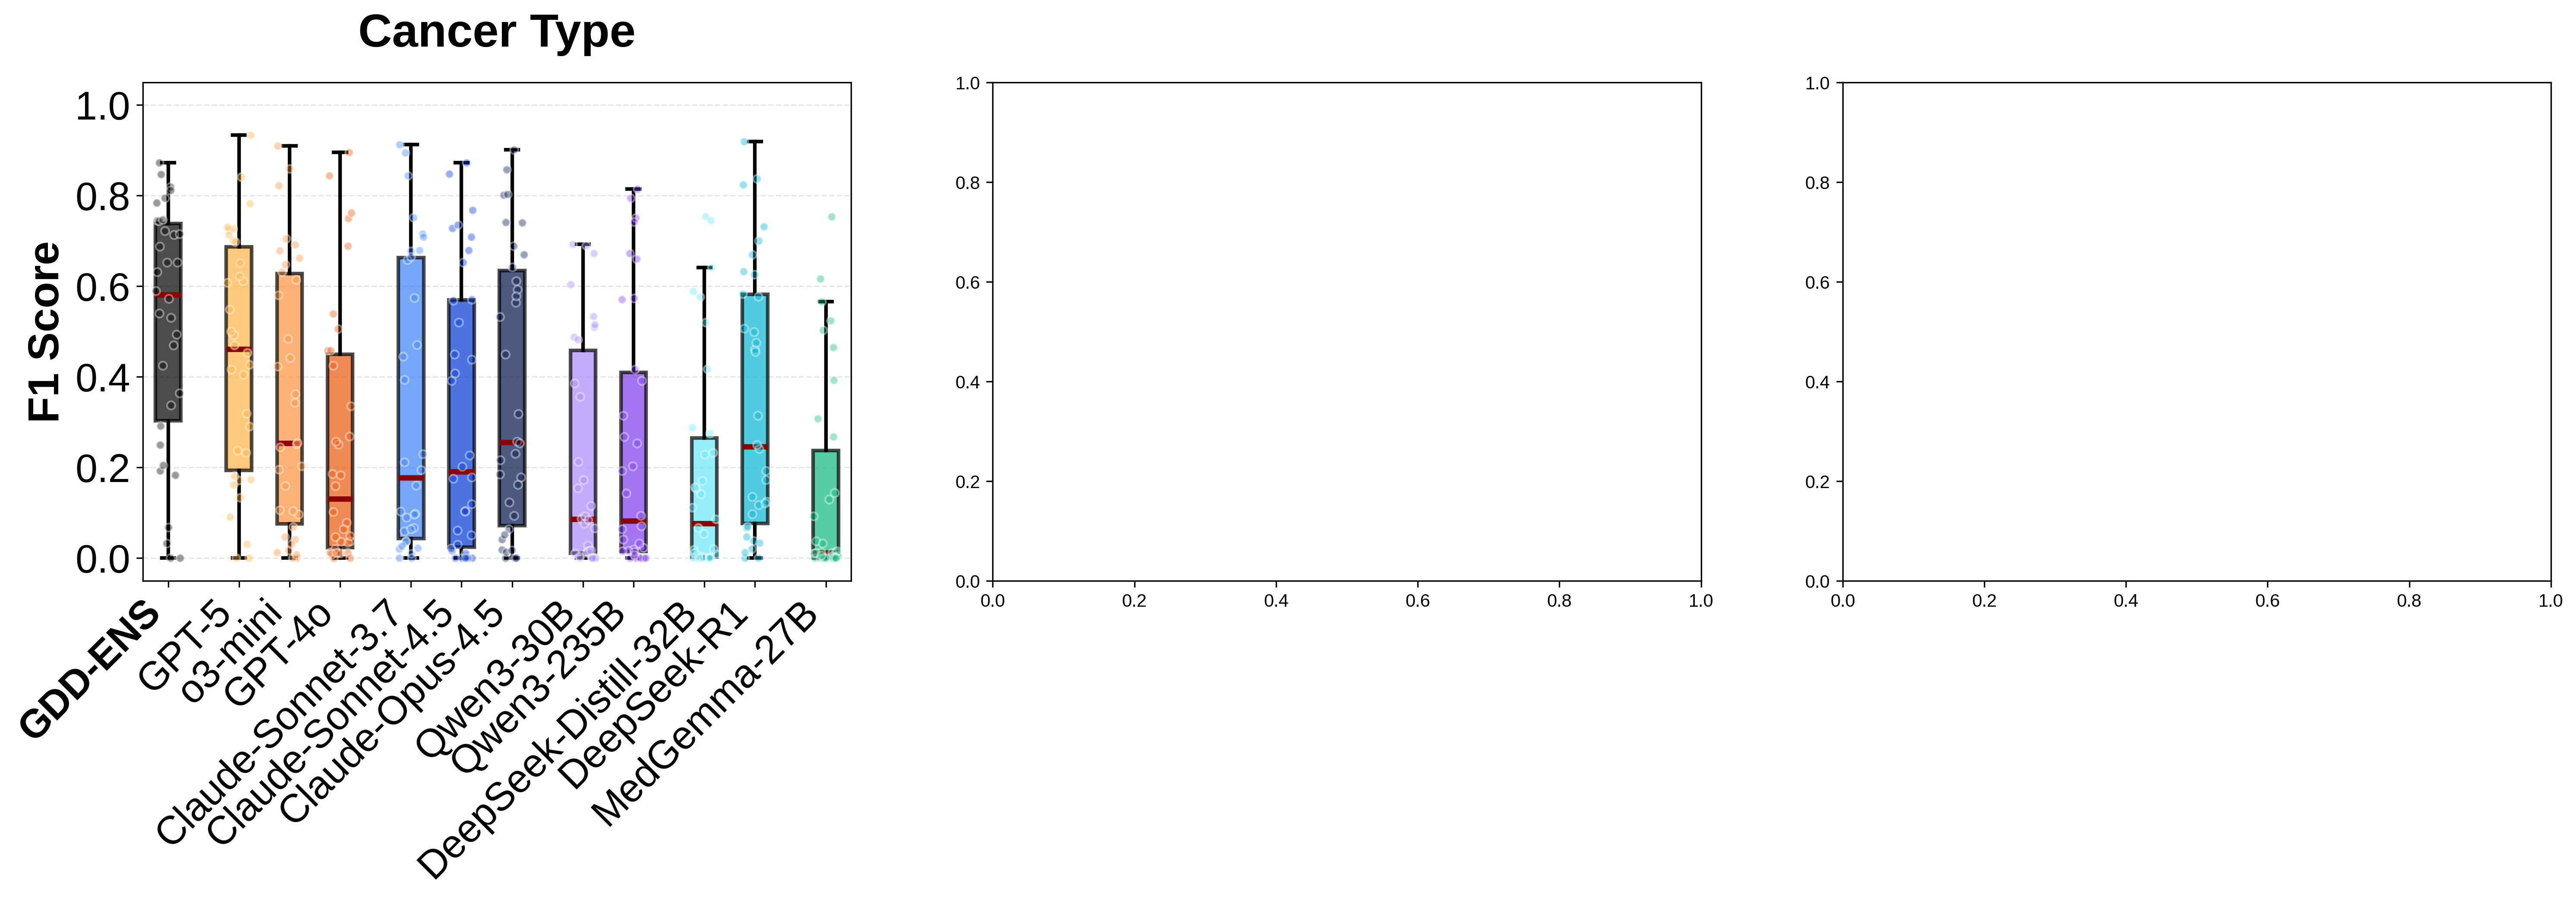


✓ Combined F1 score plot created and saved!
  - combined_analysis_plot_f1.pdf


In [24]:
# Create combined F1 score plot with 3 subplots
# Adjust subplot_wspace to control gap between subplots (smaller = tighter, e.g., 0.05)
SUBPLOT_WSPACE = 0.2  # Adjustable parameter for subplot spacing
GROUP_SPACING = 0.4    # Extra spacing between model groups

# Define model groups for spacing (same as accuracy plot)
TASK1_GROUPS = [
    ['MetaCH'],  # Baseline
    ['gpt-5', 'o3-mini', 'gpt-4o'],  # OpenAI
    ['claude-sonnet-37', 'claude-sonnet-45', 'claude-opus-45'],  # Claude
    ['qwen3', 'qwen3-vl-235b-a22b'],  # Qwen
    ['deepseek', 'deepseek-r1'],  # DeepSeek
    ['medgemma']  # MedGemma
]

TASK2_GROUPS = [
    ['AlphaMissense'],  # Baseline
    ['gpt-5', 'o3-mini', 'gpt-4o'],  # OpenAI
    ['claude-sonnet-37', 'claude-sonnet-45', 'claude-opus-45'],  # Claude
    ['qwen3', 'qwen3-vl-235b-a22b'],  # Qwen
    ['deepseek', 'deepseek-r1'],  # DeepSeek
    ['medgemma']  # MedGemma
]

TASK3_GROUPS = [
    ['GDD-ENS'],  # Baseline
    ['gpt-5', 'o3-mini', 'gpt-4o'],  # OpenAI
    ['claude-sonnet-37', 'claude-sonnet-45', 'claude-opus-45'],  # Claude
    ['qwen3', 'qwen3-vl-235b-a22b'],  # Qwen
    ['deepseek', 'deepseek-r1'],  # DeepSeek
    ['medgemma']  # MedGemma
]

# Labels to bold (baseline models)
BOLD_LABELS = ['MetaCH', 'AlphaMissense', 'GDD-ENS']

fig, axes = plt.subplots(1, 3, figsize=(24, 5), dpi=300)

# # Task 1: Mutation Status Prediction F1
# create_model_boxplot_with_dots(
#     figsize=(8, 6),
#     metrics_df=task1_f1_metrics,
#     metric_col='f1',
#     models_to_include=task1_models,
#     title='Tumor vs. CHIP',
#     y_label='F1 Score',
#     y_lim=[-0.05, 1.05],
#     fontsize=22,
#     dot_alpha=0.4,
#     dot_size=20,
#     jitter_strength=0.25,
#     ax=axes[0],
#     subplot_wspace=SUBPLOT_WSPACE,
#     bold_labels=BOLD_LABELS,
#     model_groups=TASK1_GROUPS,
#     group_spacing=GROUP_SPACING
# )

# # Task 2: Oncogenic Driver Identification F1
# create_model_boxplot_with_dots(
#     figsize=(8, 6),
#     metrics_df=task2_f1_metrics,
#     metric_col='f1',
#     models_to_include=task2_models,
#     title='Variant Oncogenicity',
#     y_label=" ",
#     y_lim=[-0.05, 1.05],
#     fontsize=22,
#     dot_alpha=0.4,
#     dot_size=20,
#     jitter_strength=0.25,
#     ax=axes[1],
#     bold_labels=BOLD_LABELS,
#     model_groups=TASK2_GROUPS,
#     group_spacing=GROUP_SPACING
# )

# Task 3: Cancer Type Classification F1
create_model_boxplot_with_dots(
    figsize=(8, 6),
    metrics_df=task3_f1_metrics,
    metric_col='f1',
    models_to_include=task3_models,
    title='Cancer Type',
    y_label='F1 Score',
    y_lim=[-0.05, 1.05],
    fontsize=22,
    dot_alpha=0.4,
    dot_size=20,
    jitter_strength=0.25,
    ax=axes[0],
    bold_labels=BOLD_LABELS,
    model_groups=TASK3_GROUPS,
    group_spacing=GROUP_SPACING
)

# plt.tight_layout()
plt.savefig('plots/combined_analysis_plot_f1_20.pdf', dpi=20, bbox_inches='tight')
plt.savefig('plots/combined_analysis_plot_f1.svg', dpi=300, bbox_inches='tight')
plt.savefig('plots/combined_analysis_plot_f1.png', dpi=300, bbox_inches='tight')

plt.show()

print("\n✓ Combined F1 score plot created and saved!")
print("  - combined_analysis_plot_f1.pdf")

In [13]:
# Calculate IQR (Q3 - Q1) for F1 scores by model
print("=====Task 1 F1 IQR=====")
iqr_by_model = task1_f1_metrics.groupby('model')['f1'].agg(
    Q1=lambda x: x.quantile(0.25),
    median=lambda x: x.quantile(0.50),
    Q3=lambda x: x.quantile(0.75),
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
).round(3)

print(iqr_by_model.sort_values('IQR'))
print("=====Task 2 F1 IQR=====")
iqr_by_model = task2_f1_metrics.groupby('model')['f1'].agg(
    Q1=lambda x: x.quantile(0.25),
    median=lambda x: x.quantile(0.50),
    Q3=lambda x: x.quantile(0.75),
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
).round(3)

print(iqr_by_model.sort_values('IQR'))
print("=====Task 3 F1 IQR=====")
iqr_by_model = task1_f1_metrics.groupby('model')['f1'].agg(
    Q1=lambda x: x.quantile(0.25),
    median=lambda x: x.quantile(0.50),
    Q3=lambda x: x.quantile(0.75),
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
).round(3)

print(iqr_by_model.sort_values('IQR'))

=====Task 1 F1 IQR=====
                       Q1  median     Q3    IQR
model                                          
qwen3               0.866   0.890  0.926  0.060
claude-opus-45      0.816   0.852  0.885  0.069
claude-sonnet-45    0.743   0.786  0.819  0.076
MetaCH              0.840   0.887  0.919  0.079
deepseek            0.822   0.875  0.911  0.089
qwen3-vl-235b-a22b  0.783   0.821  0.882  0.099
claude-sonnet-37    0.773   0.824  0.886  0.112
medgemma            0.659   0.711  0.784  0.125
deepseek-r1         0.669   0.730  0.795  0.126
gpt-4o              0.683   0.730  0.809  0.126
gpt-5               0.679   0.736  0.806  0.127
o3-mini             0.670   0.724  0.800  0.130
=====Task 2 F1 IQR=====
                       Q1  median     Q3    IQR
model                                          
AlphaMissense       0.862   0.894  0.929  0.067
gpt-5               0.796   0.856  0.905  0.109
claude-opus-45      0.766   0.834  0.882  0.115
gpt-4o              0.718   0.763  0.842

## Overall Model Performance Tables

Calculate overall accuracy, weighted F1 score, precision, and recall for all models across all three tasks (computed on the entire dataset, not per-cancer averages).

In [14]:
# Calculate OVERALL model performance for Task 1: Mutation Status Prediction
def calculate_overall_metrics(df, models, ground_truth_col='ground_truth'):
    """Calculate overall accuracy, weighted F1, precision, and recall for each model."""
    results = []
    
    for model in models:
        pred_col = f"{model}_pred"
        
        if pred_col not in df.columns:
            continue
        
        # Get valid predictions
        valid_mask = df[pred_col].notna() & df[ground_truth_col].notna()
        df_valid = df[valid_mask]
        
        if len(df_valid) == 0:
            continue
        
        y_true = df_valid[ground_truth_col]
        y_pred = df_valid[pred_col]
        
        # Calculate metrics
        accuracy = accuracy_score(y_true, y_pred) * 100
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        
        results.append({
            'Model': MODEL_DISPLAY_NAMES.get(model, model),
            'N': len(df_valid),
            'Accuracy (%)': round(accuracy, 2),
            'Weighted F1': round(f1, 4),
            'Weighted Precision': round(precision, 4),
            'Weighted Recall': round(recall, 4)
        })
    
    return pd.DataFrame(results)

# Task 1: Mutation Status Overall Performance
print("=" * 80)
print("TASK 1: MUTATION STATUS PREDICTION - OVERALL PERFORMANCE")
print("=" * 80)
task1_overall = calculate_overall_metrics(df_mutation, task1_models)
task1_overall = task1_overall.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
print(task1_overall.to_string(index=False))
print()

TASK 1: MUTATION STATUS PREDICTION - OVERALL PERFORMANCE
               Model     N  Accuracy (%)  Weighted F1  Weighted Precision  Weighted Recall
           Qwen3-30B 34415         89.93       0.8977              0.8990           0.8993
              MetaCH 34415         89.67       0.8926              0.9030           0.8967
DeepSeek-Distill-32B 34415         88.27       0.8784              0.8864           0.8827
          Qwen3-235B 34415         86.93       0.8626              0.8769           0.8693
     Claude-Opus-4.5 34415         83.57       0.8393              0.8543           0.8357
   Claude-Sonnet-4.5 34415         81.15       0.8084              0.8080           0.8115
             o3-mini 34415         80.03       0.7752              0.8299           0.8003
               GPT-5 34415         79.81       0.7778              0.8128           0.7981
              GPT-4o 34415         79.68       0.7768              0.8097           0.7968
         DeepSeek-R1 34415       

In [15]:
# Task 2: Oncogenic Driver Overall Performance
print("=" * 80)
print("TASK 2: ONCOGENIC DRIVER IDENTIFICATION - OVERALL PERFORMANCE")
print("=" * 80)
task2_overall = calculate_overall_metrics(df_oncogenic, task2_models)
task2_overall = task2_overall.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
print(task2_overall.to_string(index=False))
print()

TASK 2: ONCOGENIC DRIVER IDENTIFICATION - OVERALL PERFORMANCE
               Model     N  Accuracy (%)  Weighted F1  Weighted Precision  Weighted Recall
       AlphaMissense 13468         86.61       0.8663              0.8667           0.8661
               GPT-5 13468         77.47       0.7802              0.8245           0.7747
             o3-mini 13468         75.21       0.7464              0.7456           0.7521
     Claude-Opus-4.5 13468         75.14       0.7562              0.7701           0.7514
   Claude-Sonnet-3.7 13468         73.11       0.7324              0.7339           0.7311
         DeepSeek-R1 13468         69.91       0.6926              0.6901           0.6991
              GPT-4o 13468         69.39       0.6999              0.7150           0.6939
          Qwen3-235B 13468         68.30       0.6533              0.6621           0.6830
   Claude-Sonnet-4.5 13468         67.73       0.6822              0.6913           0.6773
        MedGemma-27B 13468  

In [16]:
# Task 3: Cancer Type Classification Overall Performance
print("=" * 80)
print("TASK 3: CANCER TYPE CLASSIFICATION - OVERALL PERFORMANCE")
print("=" * 80)
task3_overall = calculate_overall_metrics(df_cancer_clean, task3_models)
task3_overall = task3_overall.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
print(task3_overall.to_string(index=False))
print()

TASK 3: CANCER TYPE CLASSIFICATION - OVERALL PERFORMANCE
               Model      N  Accuracy (%)  Weighted F1  Weighted Precision  Weighted Recall
             GDD-ENS 102791         54.68       0.5702              0.6361           0.5468
               GPT-5 102791         48.06       0.4876              0.5229           0.4806
     Claude-Opus-4.5 102791         48.03       0.4650              0.4933           0.4803
   Claude-Sonnet-3.7 102791         44.18       0.4133              0.4528           0.4418
             o3-mini 102791         43.42       0.4218              0.4716           0.4342
   Claude-Sonnet-4.5 102791         43.11       0.4098              0.4575           0.4311
         DeepSeek-R1 102791         40.51       0.4035              0.4567           0.4051
              GPT-4o 102009         34.68       0.3209              0.3792           0.3468
          Qwen3-235B 102791         33.44       0.3106              0.3780           0.3344
           Qwen3-30B  9

In [17]:
# Create combined summary table and save to CSV
print("=" * 80)
print("COMBINED SUMMARY - ALL TASKS")
print("=" * 80)

# Add task identifier to each dataframe
task1_overall['Task'] = 'Mutation Status'
task2_overall['Task'] = 'Oncogenicity'
task3_overall['Task'] = 'Cancer Type'

# Combine all
combined_overall = pd.concat([task1_overall, task2_overall, task3_overall], ignore_index=True)

# Pivot to show tasks as columns for each metric
summary_accuracy = combined_overall.pivot(index='Model', columns='Task', values='Accuracy (%)')
summary_f1 = combined_overall.pivot(index='Model', columns='Task', values='Weighted F1')

print("\n--- Accuracy (%) by Task ---")
print(summary_accuracy.to_string())

print("\n--- Weighted F1 by Task ---")
print(summary_f1.to_string())

# Save detailed tables to CSV
task1_overall.drop(columns=['Task']).to_csv('plots/task1_mutation_status_overall_performance.csv', index=False)
task2_overall.drop(columns=['Task']).to_csv('plots/task2_oncogenicity_overall_performance.csv', index=False)
task3_overall.drop(columns=['Task']).to_csv('plots/task3_cancer_type_overall_performance.csv', index=False)
combined_overall.to_csv('plots/all_tasks_overall_performance.csv', index=False)

print("\n✓ Tables saved to plots/ directory")

COMBINED SUMMARY - ALL TASKS

--- Accuracy (%) by Task ---
Task                  Cancer Type  Mutation Status  Oncogenicity
Model                                                           
AlphaMissense                 NaN              NaN         86.61
Claude-Opus-4.5             48.03            83.57         75.14
Claude-Sonnet-3.7           44.18            78.67         73.11
Claude-Sonnet-4.5           43.11            81.15         67.73
DeepSeek-Distill-32B        24.01            88.27         65.84
DeepSeek-R1                 40.51            78.82         69.91
GDD-ENS                     54.68              NaN           NaN
GPT-4o                      34.68            79.68         69.39
GPT-5                       48.06            79.81         77.47
MedGemma-27B                20.90            75.50         65.90
MetaCH                        NaN            89.67           NaN
Qwen3-235B                  33.44            86.93         68.30
Qwen3-30B                   25.